In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from spline_filter.tensorflow.distribution import SimpleDensityEstimator

## Train PDF

In [3]:
estimator = SimpleDensityEstimator(10, dtype=tf.float64)
# estimator = SimpleDensityEstimator([0.0, 0.25, 0.3, 0.35, 0.75, 0.8, 1.0])

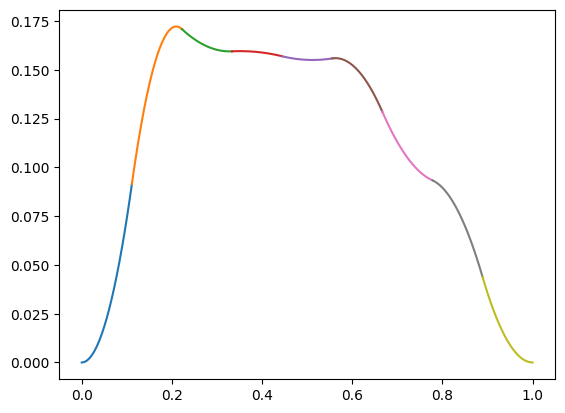

In [4]:
estimator.get_spline().plot()

In [5]:
estimator.expected_value().numpy()

0.45474037183180077

In [6]:
estimator.area().numpy()

0.1111111111111111

In [7]:
import tensorflow as tf
import numpy as np

In [8]:
ts = tf.convert_to_tensor(np.random.normal(0.5, 0.05, size=100_000))

In [9]:
estimator.train(ts, n_epochs=20, batch_size=4096)

Epoch 1/20 44.37028389647204
Epoch 2/20 43.788878710543116
Epoch 3/20 43.22569140649869
Epoch 4/20 42.68100503547876
Epoch 5/20 42.15417496559016
Epoch 6/20 41.644324280921786
Epoch 7/20 41.15048166708143
Epoch 8/20 40.67159927268477
Epoch 9/20 40.206554113022236
Epoch 10/20 39.7541482600243
Epoch 11/20 39.31311027936432
Epoch 12/20 38.88209922502115
Epoch 13/20 38.4597127238496
Epoch 14/20 38.044500957819686
Epoch 15/20 37.63498839000105
Epoch 16/20 37.229704652359246
Epoch 17/20 36.82722491136939
Epoch 18/20 36.42621819132065
Epoch 19/20 36.02549981879291
Epoch 20/20 35.624082005316815


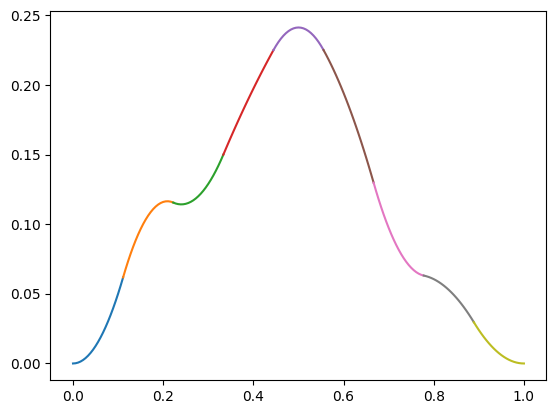

In [10]:
estimator.get_spline().plot()

In [11]:
estimator.expected_value().numpy()

0.4695691889154206

In [12]:
estimator.area().numpy()

0.1111111111111111

## Train CDF

In [13]:
estimator = SimpleDensityEstimator(7, dtype=tf.float64)
# estimator = SimpleDensityEstimator([0.0, 0.25, 0.3, 0.35, 0.75, 0.8, 1.0])

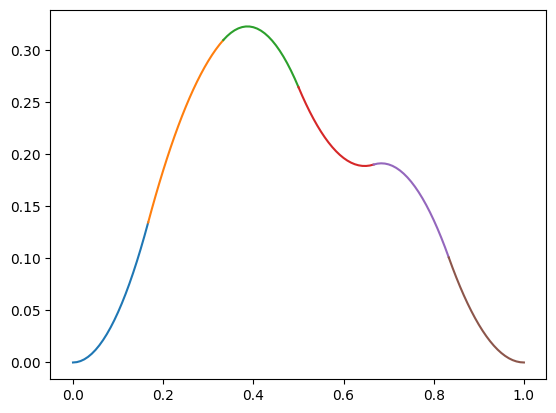

In [14]:
estimator.get_spline().plot()

In [15]:
estimator.expected_value().numpy()

0.4688449515968005

In [16]:
ts = tf.convert_to_tensor(np.random.normal(0.5, 0.05, size=10_000), dtype=tf.float64)
# t_preds = tf.convert_to_tensor(np.random.uniform(size=100_000), dtype=tf.float64)
t_preds = estimator.get_cdf_spline().sample(10_000)
over_pred_vec = tf.where(t_preds > ts, 1.0, 0.0)

In [17]:
estimator.train_cdf(t_preds, over_pred_vec, n_epochs=20, batch_size=1024)

Epoch 1/20 3.0406197542183175
Epoch 2/20 3.0288852698237254
Epoch 3/20 3.017359272425096
Epoch 4/20 3.0060543481629898
Epoch 5/20 2.994975584391837
Epoch 6/20 2.9841213452357156
Epoch 7/20 2.9734855817521515
Epoch 8/20 2.9630596876190074
Epoch 9/20 2.952833727590557
Epoch 10/20 2.942797162852555
Epoch 11/20 2.9329392594223984
Epoch 12/20 2.9232493231391565
Epoch 13/20 2.913716848079546
Epoch 14/20 2.9043316239765575
Epoch 15/20 2.895083823868315
Epoch 16/20 2.885964080324276
Epoch 17/20 2.876963552286477
Epoch 18/20 2.868073981765248
Epoch 19/20 2.8592877386818434
Epoch 20/20 2.8505978521965156


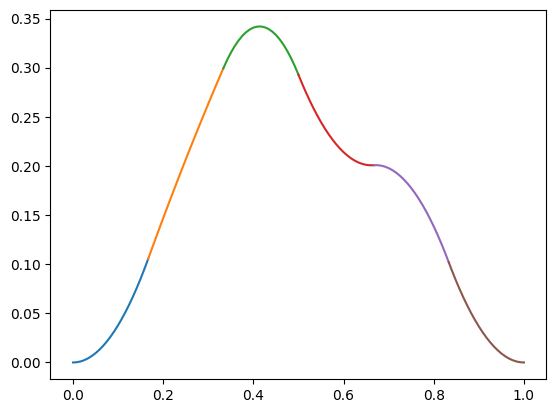

In [18]:
estimator.get_spline().plot()

In [19]:
estimator.expected_value().numpy()

0.4824008514009436

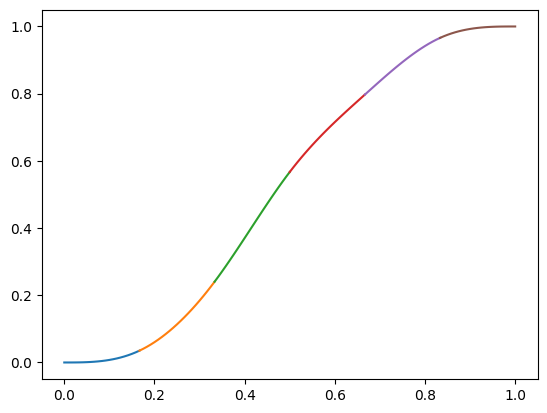

In [20]:
estimator.get_cdf_spline().plot()

## Auction scenario?

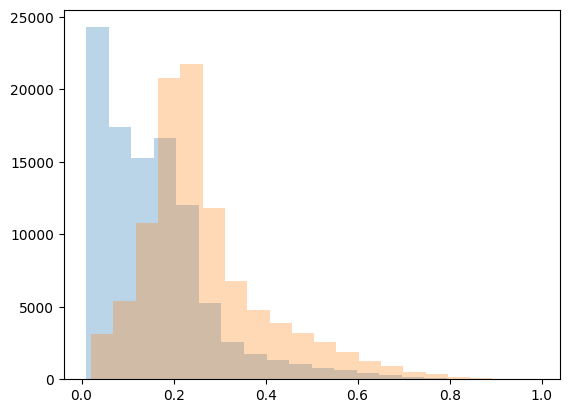

In [80]:
n_bidders = 5
n_items = 100_000

def positive_normal(loc, sd, size=1):
    values = np.random.normal(loc, sd, size=size)
    positive_values = values.reshape(-1).tolist()
    return np.where(values < 0.01, np.random.choice(positive_values, replace=True, size=size), values)

## Throwing money around theory
high_supply_chance = 0.5
desired_chance = 0.2
supply_p = np.random.uniform(size=(n_items, n_bidders))
desired_p = np.random.uniform(size=(n_items, n_bidders))
demand = np.where(  # high money, high demand
    (supply_p < high_supply_chance) & (desired_p < desired_chance),
    positive_normal(0.30, 0.20, size=(n_items, n_bidders)),
    np.where(  # low money, high demand
        (supply_p >= high_supply_chance) & (desired_p < desired_chance),
        positive_normal(0.20, 0.04, size=(n_items, n_bidders)),
        np.where(  # high money, low demand
            (supply_p < high_supply_chance) & (desired_p >= desired_chance),
            positive_normal(0.10, 0.10, size=(n_items, n_bidders)),
            # low money, low demand
            positive_normal(0.03, 0.02, size=(n_items, n_bidders)),
        )
    )
)
demand = np.clip(demand, a_min=0.01, a_max=0.99)

lowball_chance = 0.7
lowball_p = np.random.uniform(size=(n_items, n_bidders))
medians = np.median(demand, axis=1)
medians = np.hstack([medians.reshape(n_items, 1)] * n_bidders)
                         
bids = np.where(lowball_p < lowball_chance, np.minimum(medians, demand), demand)
normal_winning_bids = np.max(bids, axis=1)
max_winning_bids = np.max(demand, axis=1)

plt.hist(normal_winning_bids, bins=20, alpha=0.3)
plt.hist(max_winning_bids, bins=20, alpha=0.3)
plt.show()

## Attempting to hide real desire
# desired_chance = 0.2
# low_bids = np.random.normal(0.08, 0.03, size=(n_items, n_bidders))
# winning_low_bids = np.max(low_bids, axis=1)

# plt.hist(low_bids.reshape(-1), density=True, bins=20, alpha=0.3)
# plt.hist(winning_low_bids, density=True, bins=20, alpha=0.3)
# plt.show()

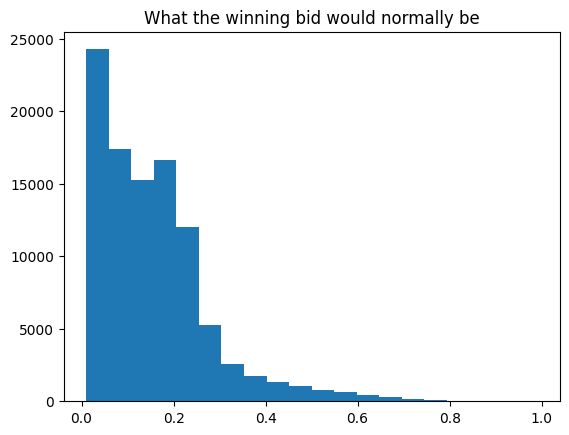

In [81]:
import matplotlib.pyplot as plt
plt.hist(normal_winning_bids, bins=20)
plt.title('What the winning bid would normally be')
plt.show()

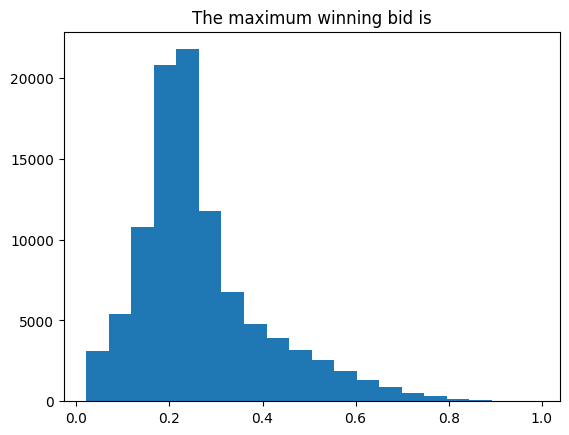

In [82]:
plt.hist(max_winning_bids, bins=20)
plt.title('The maximum winning bid is')
plt.show()

In [93]:
normal_winning_bids.mean()

0.1571098988034519

In [94]:
max_winning_bids.mean()

0.26813989975211067

In [84]:
bid_estimator = SimpleDensityEstimator([0.0, 0.005, 0.01, 0.02, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.65, 0.80, 1.00])

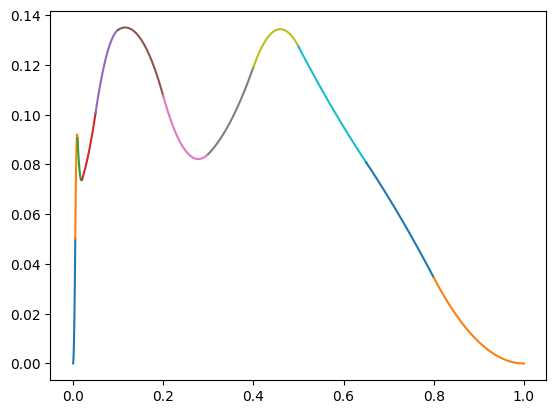

In [89]:
bid_estimator.get_spline().plot()

In [90]:
bid_estimator.train(normal_winning_bids, n_epochs=30, batch_size=1024)

Epoch 1/30 212.3687716199042
Epoch 2/30 205.24389214337586
Epoch 3/30 199.15545887714939
Epoch 4/30 193.99870803974352
Epoch 5/30 189.66024281235167
Epoch 6/30 186.02660934952567
Epoch 7/30 182.99111831082124
Epoch 8/30 180.45785308906244
Epoch 9/30 178.34331127750897
Epoch 10/30 176.57642532951496
Epoch 11/30 175.09763638265088
Epoch 12/30 173.85752120856915
Epoch 13/30 172.81529738538075
Epoch 14/30 171.937393496588
Epoch 15/30 171.1961755531204
Epoch 16/30 170.56886119664404
Epoch 17/30 170.03661967272268
Epoch 18/30 169.5838390874347
Epoch 19/30 169.19753627496587
Epoch 20/30 168.86688407023476
Epoch 21/30 168.58283300274536
Epoch 22/30 168.33780773845237
Epoch 23/30 168.12546211166702
Epoch 24/30 167.9404798757933
Epoch 25/30 167.7784111643972
Epoch 26/30 167.63553701929078
Epoch 27/30 167.50875620651072
Epoch 28/30 167.39548994836284
Epoch 29/30 167.29360122647702
Epoch 30/30 167.20132604875042


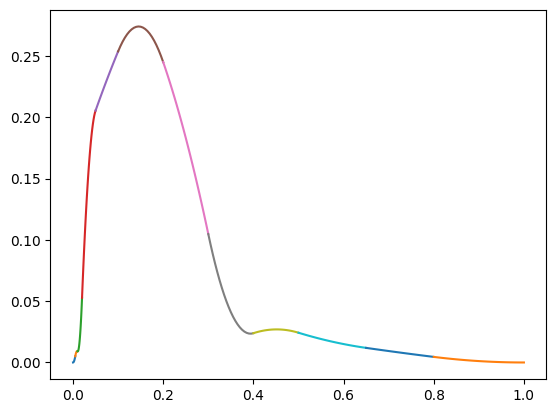

In [91]:
bid_estimator.get_spline().plot()

In [92]:
bid_estimator.expected_value().numpy()

0.20677915022002807

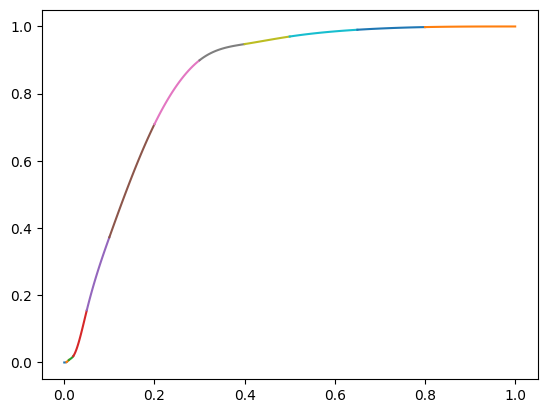

In [95]:
bid_estimator.get_cdf_spline().plot()

#### Look at it, it's beautiful

Now I want to train a distribution that looks at what happens if we interfere

In [99]:
floor_estimator = SimpleDensityEstimator([0.0, 0.005, 0.01, 0.02, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.65, 0.80, 1.00])

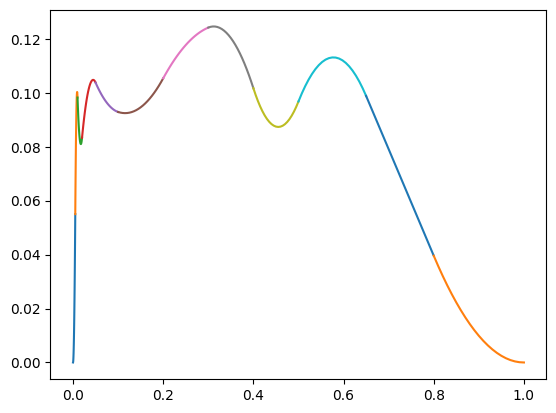

In [100]:
floor_estimator.get_spline().plot()

In [101]:
floors = np.random.uniform(0.01, 0.99, size=100_000)
new_bids = np.where(floors > max_winning_bids, 0.0, np.maximum(floors, normal_winning_bids))
over_pred_vec = (new_bids == 0).astype(int)

In [102]:
floor_estimator.train_cdf(
    tf.convert_to_tensor(floors, dtype=tf.float64),
    tf.convert_to_tensor(over_pred_vec, dtype=tf.float64),
    n_epochs=20,
    batch_size=1024)

Epoch 1/20 29.353310323682354
Epoch 2/20 28.643513520527627
Epoch 3/20 28.002663058509064
Epoch 4/20 27.429547592699652
Epoch 5/20 26.92012424860805
Epoch 6/20 26.470886473880558
Epoch 7/20 26.07944179330979
Epoch 8/20 25.743267297611975
Epoch 9/20 25.45860569518393
Epoch 10/20 25.220321806021957
Epoch 11/20 25.02244185606165
Epoch 12/20 24.85884624371631
Epoch 13/20 24.723792416292895
Epoch 14/20 24.612189588492413
Epoch 15/20 24.51968112125758
Epoch 16/20 24.442620585287283
Epoch 17/20 24.378005184617916
Epoch 18/20 24.323398222352672
Epoch 19/20 24.276850985997687
Epoch 20/20 24.236826145085384


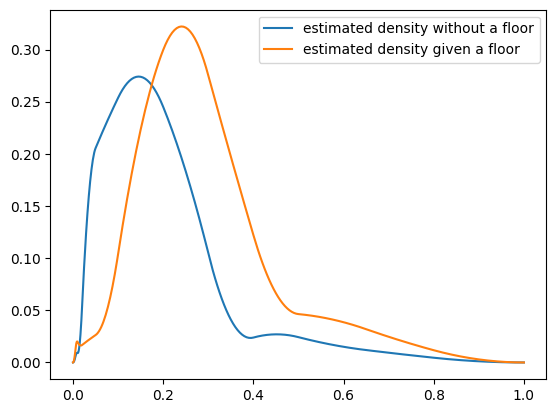

In [103]:
bid_estimator.get_spline().plot(segmented=False, label='estimated density without a floor')
floor_estimator.get_spline().plot(segmented=False, label='estimated density given a floor')
plt.legend()
plt.show()

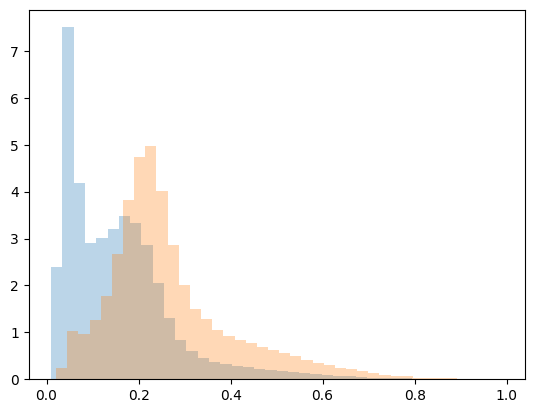

In [104]:
plt.hist(normal_winning_bids, bins=40, density=True, alpha=0.3)
plt.hist(max_winning_bids, bins=40, density=True, alpha=0.3)
plt.show()

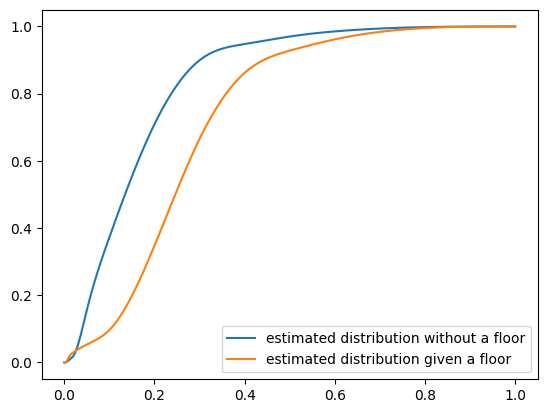

In [105]:
bid_estimator.get_cdf_spline().plot(segmented=False, label='estimated distribution without a floor')
floor_estimator.get_cdf_spline().plot(segmented=False, label='estimated distribution given a floor')
plt.legend()
plt.show()

In [106]:
bid_estimator.expected_value().numpy(), floor_estimator.expected_value().numpy()

(0.20677915022002807, 0.2991007401107611)

In [107]:
np.mean(normal_winning_bids), np.mean(new_bids), np.mean(max_winning_bids)

(0.1571098988034519, 0.0653878057790701, 0.26813989975211067)

In [109]:
bid_cdf = bid_estimator.get_cdf_spline()
floor_cdf = floor_estimator.get_cdf_spline()

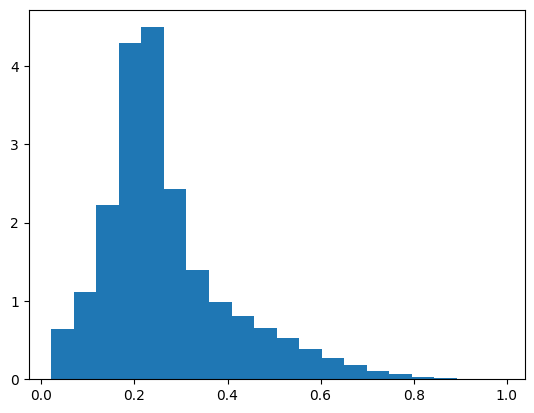

In [149]:
plt.hist(max_winning_bids, density=True, bins=20)
plt.show()

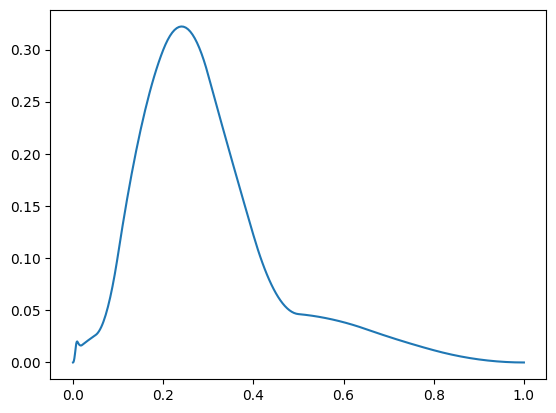

In [158]:
floor_estimator.get_spline().plot(segmented=False)

In [146]:
from tqdm import tqdm

bid_cdf = bid_estimator.get_cdf_spline()
floor_cdf = floor_estimator.get_cdf_spline()

def expected_value_w_floor(floor):
    pta = bid_cdf.get_y(floor)
    ptb = floor_cdf.get_y(floor)
    return (pta - ptb) * floor + bid_estimator.expected_value(floor).numpy()

all_floors = np.arange(0.01, 1.0, 0.01).tolist()
exp_vals = [expected_value_w_floor(x) for x in tqdm(all_floors)]
best_floor = all_floors[np.argmax(exp_vals)]
best_exp_val = max(exp_vals)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 99/99 [00:42<00:00,  2.35it/s]


In [160]:
def actual_value_w_floor(floor):
    new_bids = np.where(floor > max_winning_bids, 0.0, np.maximum(floors, normal_winning_bids))
    return new_bids.mean()

actual_vals = [actual_value_w_floor(x) for x in all_floors]
actual_best_floor = all_floors[np.argmax(actual_vals)]
actual_best_val = max(actual_vals)

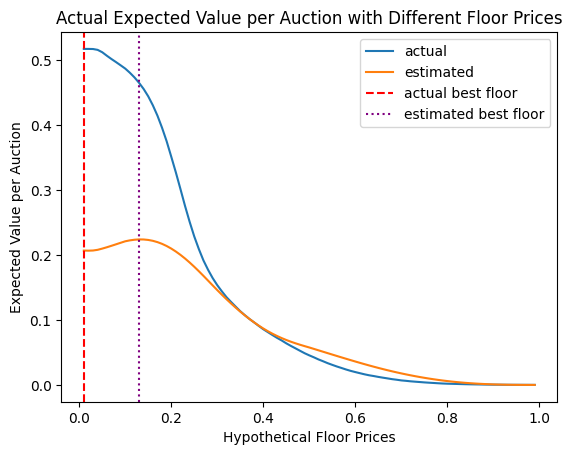

In [161]:
plt.plot(all_floors, actual_vals, label='actual')
plt.plot(all_floors, exp_vals, label='estimated')

plt.axvline(actual_best_floor, color='red', linestyle='--', label='actual best floor')
plt.axvline(best_floor, color='purple', linestyle=':', label='estimated best floor')

plt.legend()
plt.title('Actual Expected Value per Auction with Different Floor Prices')
plt.xlabel('Hypothetical Floor Prices')
plt.ylabel('Expected Value per Auction')

plt.show()

12

In [186]:
x.ma

array([ 0.0956799 , -0.01035289,  0.04898912])

In [190]:
best_floor, num, y, x, smol_num

(0.13, 13, 0.1501061582104235, 0.09567990008408057, 9)

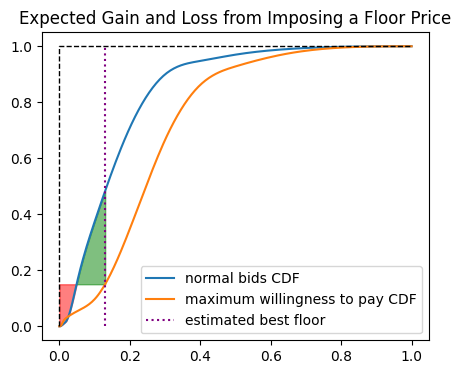

In [199]:
plt.figure(figsize=(5, 4))
bid_cdf.plot(segmented=False, label='normal bids CDF')
floor_cdf.plot(segmented=False, label='maximum willingness to pay CDF')

num = sum(int(best_floor >= f) for f in all_floors)
y = floor_cdf.get_y(best_floor)
curve = bid_cdf.get_curve(bid_cdf.get_curve_index(y)[0])
x = np.median(curve.solve(y))  # TODO: I don't remember how to pick the right solution out of the three possible ones
smol_num = sum(int(x >= f) for f in all_floors)

plt.plot([0, 0, 1], [0, 1, 1], color='black', linestyle='--', lw=1)
plt.plot([best_floor]*2, [0, 1], color='purple', linestyle=':', label='estimated best floor')
plt.fill_between(
    [0] + all_floors[:smol_num] + [x],
    [0] + bid_cdf.get_y_batched(np.array(all_floors[:smol_num] + [x])).tolist(),
    [y] * (smol_num + 2),
    color='red',
    alpha=0.5)
plt.fill_between(
    [x] + all_floors[smol_num:num],
    [y] * (num - smol_num + 1),
    [y] + bid_cdf.get_y_batched(np.array(all_floors[smol_num:num])).tolist(),
    color='green',
    alpha=0.5)

plt.title('Expected Gain and Loss from Imposing a Floor Price')
plt.legend()
plt.show()

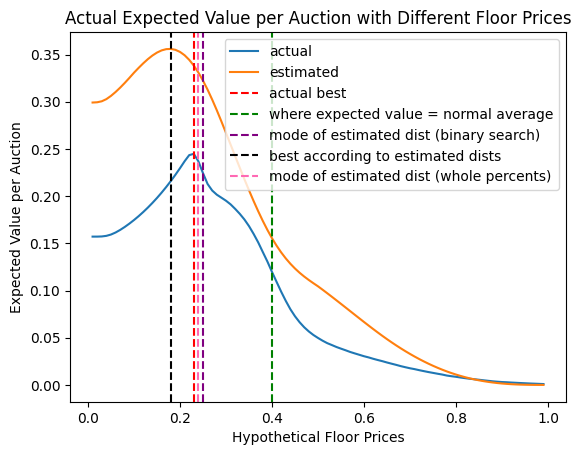

In [157]:
# bid_cdf = bid_estimator.get_cdf_spline()
# floor_cdf = floor_estimator.get_cdf_spline()

# hyp_floors = np.arange(0.01, 1.0, 0.01)
# e_values = [np.where(f > (normal_winning_bids + 0.20), 0.0, np.maximum(normal_winning_bids, f)).mean() for f in hyp_floors]
# # e_values2 = [floor_estimator.expected_value(f) for f in hyp_floors
# # hacky way to try to get an expected value, one which I am rethinking
# e_values2 = [floor_estimator.expected_value(f) + bid_cdf.get_y(f) * (1 - floor_cdf.get_y(f)) * f for f in hyp_floors]

# plt.plot(hyp_floors, e_values, label='actual')
# plt.plot(hyp_floors, e_values2, label='estimated')

# plt.axvline(hyp_floors[np.argmax(e_values)], color='red', linestyle='--', label='actual best')
# plt.axvline(optimal_floor, color='green', linestyle='--', label='where expected value = normal average')
# plt.axvline(optimal_floor2, color='purple', linestyle='--', label='mode of estimated dist (binary search)')
# plt.axvline(hyp_floors[np.argmax(e_values2)], color='black', linestyle='--', label='best according to estimated dists')
# plt.axvline(most_dense_t, color='hotpink', linestyle='--', label='mode of estimated dist (whole percents)')

# # plt.legend(['actual', 'estimated'])
# plt.legend()
# plt.title('Actual Expected Value per Auction with Different Floor Prices')
# plt.xlabel('Hypothetical Floor Prices')
# plt.ylabel('Expected Value per Auction')

# plt.show()

### Notes on the SimpleDensityEstimator

Not a great proof-of-concept yet. The contrived auction simulation is flawed. I'll need a more educated and realistic model of how auction bidders behave before we can say that it is any good. There is also a flaw with the `train_cdf` method. The beginning and end of the distribution learns *too* much. The beginning and end points are *always* learning because their values always affect either the CDF value or the SF value. I don't know if that means that I need to weight the gradients somehow or if that means I need to rebalance the data. But first I want to see if making the knot values trainable fixes this problem or not.

UPDATE: Alright, I have concluded that the flexible density estimator suffers from the same problem so I left the work for that at the end of the notebook and am continuing with a new idea, Thompson Sampling.

### Thompson Sampling

We can have the bid_estimator like before, but the floors are going to be chosen randomly from the estimator first. That is, if I can prove that it is even possible to draw a sample from a spline representing a CDF. So that's got to happen first.

In [52]:
cdf = bid_estimator.get_cdf_spline()

In [53]:
len(cdf.end_points)

14

In [54]:
len(cdf.points)

16

In [55]:
len(cdf.knots)

20

In [56]:
midpoints = (cdf.points[:-1] + cdf.points[1:]) / 2

In [57]:
ind = cdf.get_curve_index(midpoints[2])[0]

In [58]:
curve = cdf.get_curve(ind)
curve

Curve(a=-59.394, b=29.510, c=-2.270, d=0.058)

In [59]:
p, q = curve.get_p_q(midpoints[2])
p, q

(-0.04406906098842318, -0.0021613208067593256)

In [60]:
cond = (p/3)**3 + (q/2)**2 > 0
cond

False

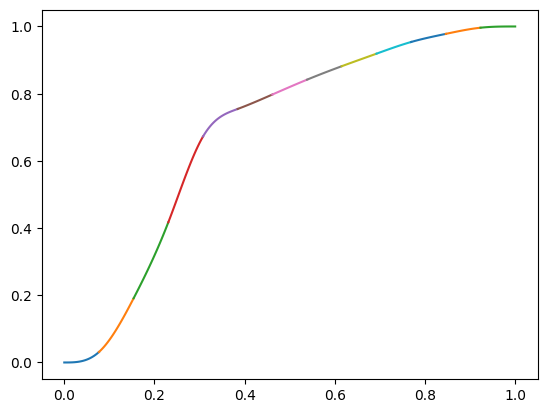

In [61]:
cdf.plot()

In [62]:
import math
math.pi, np.pi

(3.141592653589793, 3.141592653589793)

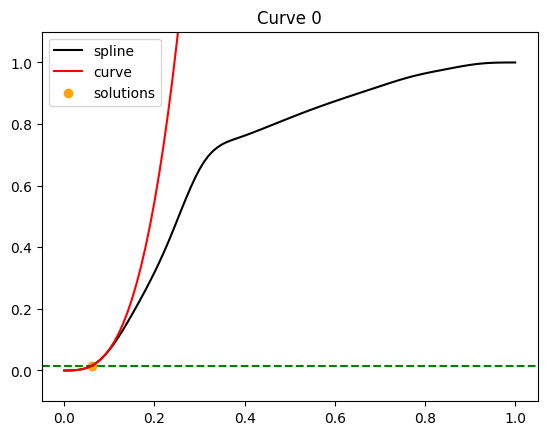

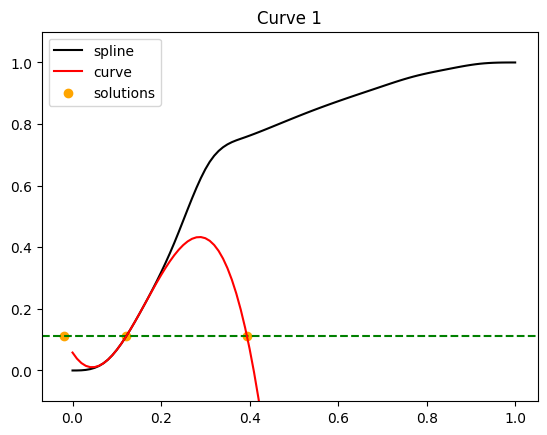

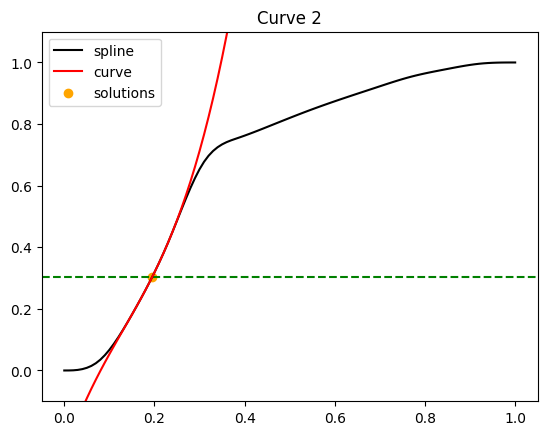

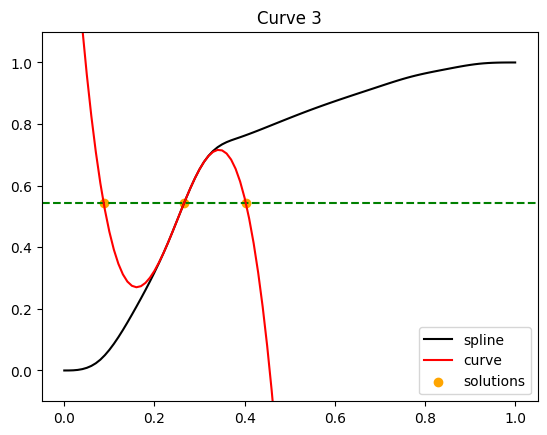

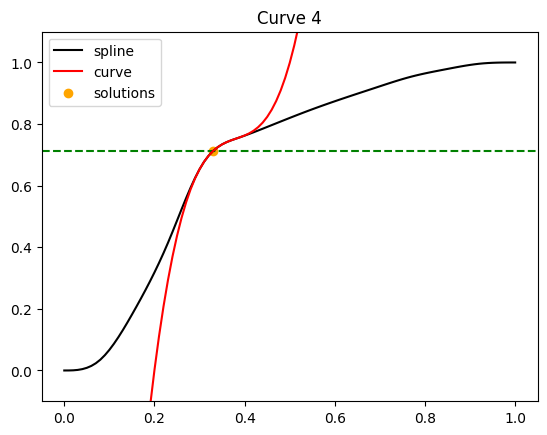

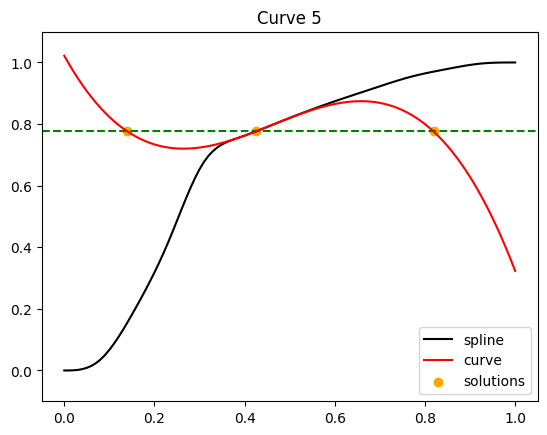

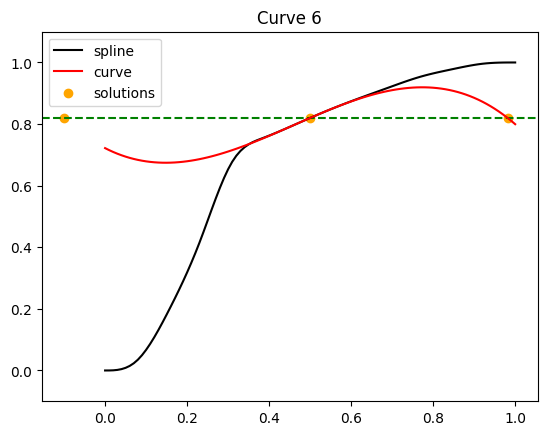

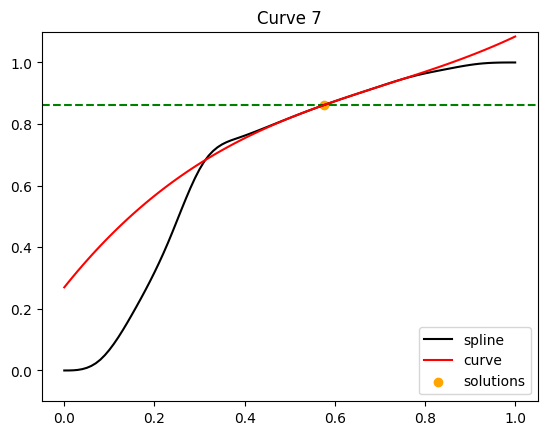

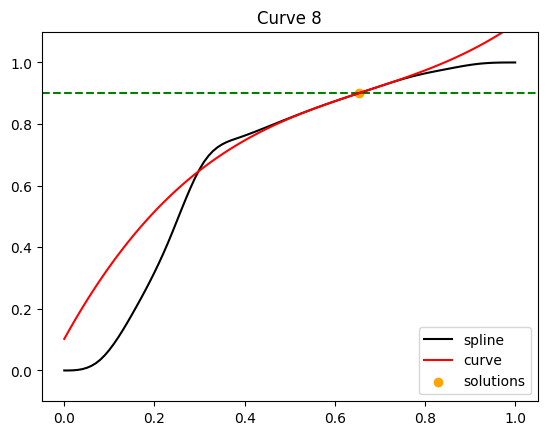

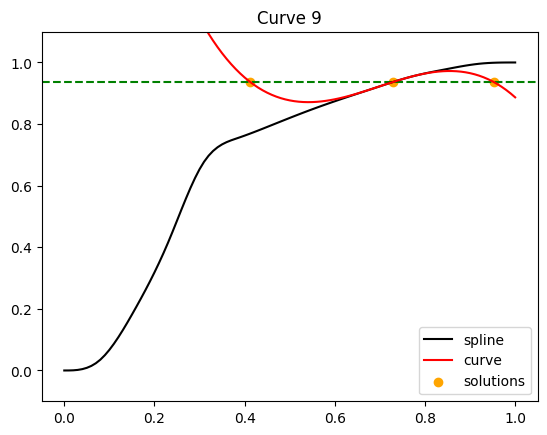

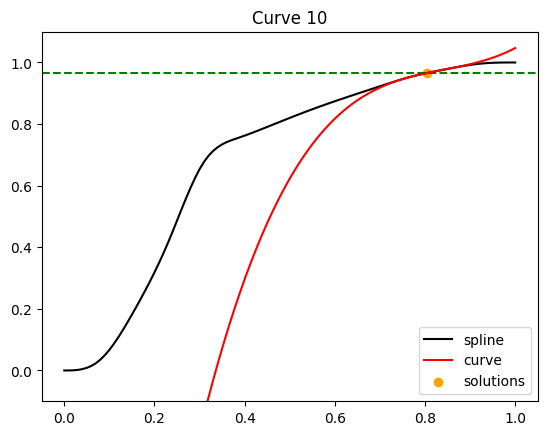

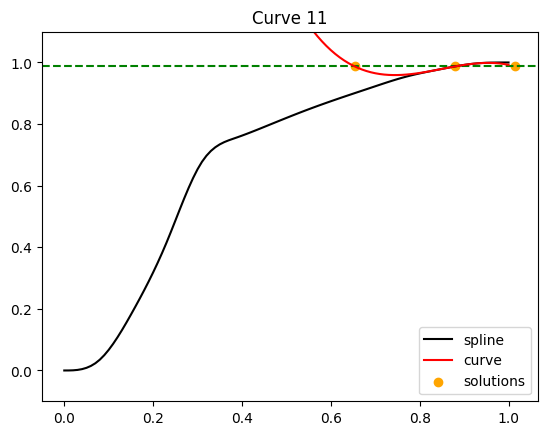

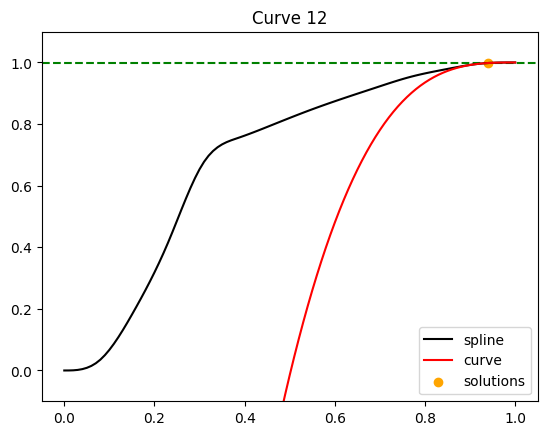

In [63]:
midpoints = (cdf.end_points[:-1] + cdf.end_points[1:]) / 2

failures = 0
for midpoint in midpoints:
    curve_ind = cdf.get_curve_index(midpoint)[0]
    curve = cdf.get_curve(curve_ind)
    solutions = curve.solve(midpoint)

    ts = np.linspace(0, 1, 101)
    spline_ys = cdf.get_y_batched(ts)
    curve_ys = curve(ts)

    plt.axhline(midpoint, color='green', linestyle='--')
    plt.plot(ts, spline_ys, color='black', label='spline')
    plt.plot(ts, curve_ys, color='red', label='curve')
    plt.scatter(solutions, np.array([midpoint] * solutions.shape[0]), color='orange', label='solutions')
    plt.title(f'Curve {curve_ind}')
    plt.legend()
    plt.ylim(-0.1, 1.1)
    plt.show()
    

### Lol, we can sample now XD bahahahahahahaha what a stupid amount of work to make this functional

In [64]:
# I can't believe this is actually not slow at all
cdf.sample(10)

array([0.75174848, 0.2026345 , 0.27865274, 0.29204071, 0.28285256,
       0.13528843, 0.45778057, 0.24525382, 0.27099489, 0.20737703])

In [65]:
normal_bids.shape

(100000,)

In [85]:
# This is the original code for training the thompson sampler
# the cell below is a cannibalization of this code; I really wanted to preserve this one
from tqdm import trange

batch_size = 1000
buffer_size = 4000
n_epochs = 5

# replay buffer-ish type thing? 4000
bids = []
floors = []
other_new_bids = [] # So we can compare actual revenue from this strategy against uniform sampling

# brand new density estimator
thompson_sampler = SimpleDensityEstimator(12)

for i in trange(0, normal_bids.shape[0], batch_size):
    bids.extend(normal_bids[i:i+batch_size])
    floors.extend(thompson_sampler.get_cdf_spline().sample(1000))
    bids = bids[max(0, len(bids) - buffer_size):]
    floors = floors[max(0, len(floors) - buffer_size):]
    
    cond = np.array(floors) > np.array(bids) * 1.2
    over_pred_vec = cond.astype(int).astype(np.float64)
    other_new_bids.extend(np.where(
        cond[-batch_size:],
        0.0,
        np.maximum(
            np.array(bids[-batch_size:]),
            np.array(floors[-batch_size:])
        )
    ))
    
    thompson_sampler.train_cdf(np.array(floors), over_pred_vec, n_epochs=n_epochs, batch_size=batch_size, verbose=False)



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [01:38<00:00,  1.02it/s]


In [89]:
type(bids)

numpy.ndarray

In [96]:
# this and the next two cells contain a monster is for creating an animated gif
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
from tqdm import tqdm

batch_size = 1000
buffer_size = 4000
n_epochs = 8

# replay buffer-ish type thing? 4000
bids = []
floors = []
other_new_bids = [] # So we can compare actual revenue from this strategy against uniform sampling

saving the animation


101it [01:59,  1.18s/it]                                                                                                                                               


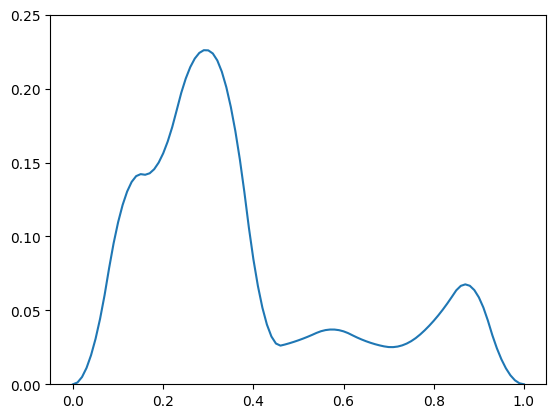

In [97]:
# brand new density estimator
thompson_sampler = SimpleDensityEstimator(12)

ts = np.linspace(0, 1, 101)
fig, ax = plt.subplots()
ax.set_ylim(0, 0.25)
density_plot, = ax.plot(ts, thompson_sampler.get_spline().get_y_batched(ts))

def train_sampling_episode(i):
    global batch_size, buffer_size, n_epochs, bids, floors, other_new_bids
    i = i * batch_size
    bids.extend(normal_bids[i:i+batch_size])
    floors.extend(thompson_sampler.get_cdf_spline().sample(1000))
    bids = bids[max(0, len(bids) - buffer_size):]
    floors = floors[max(0, len(floors) - buffer_size):]
    
    cond = np.array(floors) > np.array(bids) * 1.2
    over_pred_vec = cond.astype(int).astype(np.float64)
    other_new_bids.extend(np.where(
        cond[-batch_size:],
        0.0,
        np.maximum(
            np.array(bids[-batch_size:]),
            np.array(floors[-batch_size:])
        )
    ))
    
    thompson_sampler.train_cdf(np.array(floors), over_pred_vec, n_epochs=n_epochs, batch_size=batch_size, verbose=False)

print('saving the animation')
with tqdm(total=100) as pbar:
    def animate(i):
        global ax, density_plot
        train_sampling_episode(i)
        ys = thompson_sampler.get_spline().get_y_batched(ts)
        density_plot.set_ydata(ys)
        pbar.update(1)
        return (density_plot,)
    
    ani = animation.FuncAnimation(fig, animate, repeat=True, frames=100, interval=40)
    
    # To save the animation using Pillow as a gif
    writer = animation.PillowWriter(fps=25,
                                    metadata=dict(artist='Me'),
                                    bitrate=1800)
    ani.save('thompson_sampler_training.gif', writer=writer)

In [98]:
bids = np.array(bids)
floors = np.array(floors)
other_new_bids = np.array(other_new_bids)

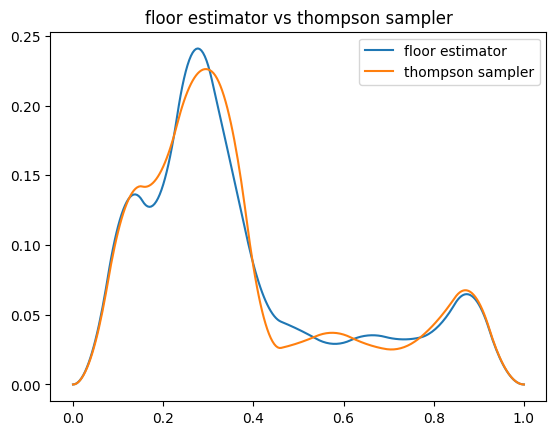

In [99]:
floor_estimator.get_spline().plot(segmented=False, label='floor estimator')
thompson_sampler.get_spline().plot(segmented=False, label='thompson sampler')
plt.title('floor estimator vs thompson sampler')
plt.legend()
plt.show()

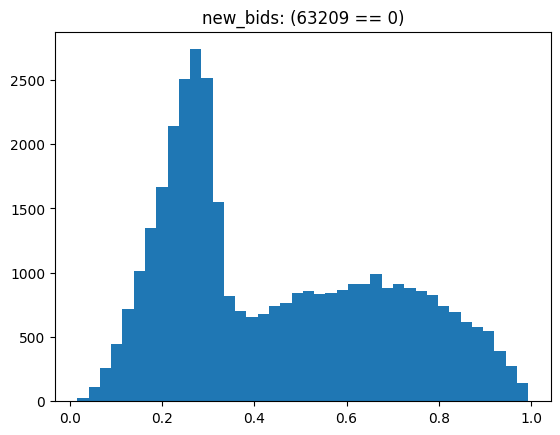

In [100]:
plt.hist(new_bids[np.where(new_bids != 0)], bins=40)
plt.title('new_bids: (' + str((new_bids == 0).sum()) + ' == 0)')
plt.show()

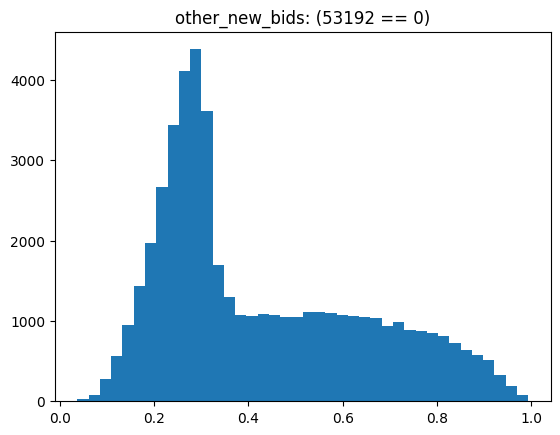

In [101]:
plt.hist(np.array(other_new_bids)[np.where(other_new_bids != 0)], bins=40)
plt.title('other_new_bids: (' + str((np.array(other_new_bids) == 0).sum()) + ' == 0)')
plt.show()

In [103]:
max_bids = np.minimum(1.0, normal_bids * 1.2)

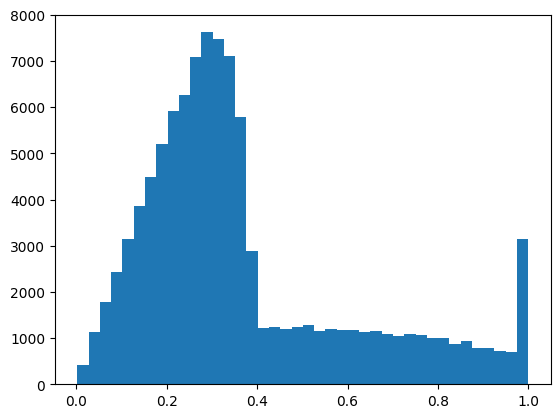

In [104]:
plt.hist(max_bids, bins=40)
plt.show()

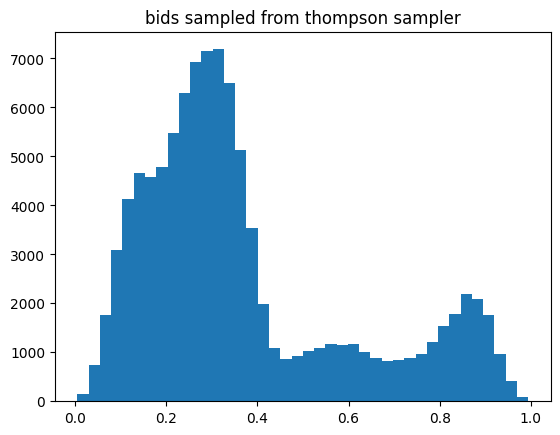

In [105]:
plt.hist(thompson_sampler.get_cdf_spline().sample(100_000), bins=40)
plt.title('bids sampled from thompson sampler')
plt.show()

In [106]:
np.mean(normal_bids), np.mean(new_bids), np.mean(other_new_bids), np.mean(max_bids)

(0.310216693186641, 0.1655206995920033, 0.20427948397700355, 0.370531232988375)

That's fascinating. The Thompson sampler was better at staying under the threshold and it generated more revenue that the uniformly sampled floors. It also seems to have a smoother distribution. There's less of a peak at the end on the right side. Thinking about it now, it makes a ton of sense for the altered distribution to have a peak near the end because of all the max bids that are greater than the domain of the space (>1.0). Also fascinating that the thompson sampler differs from the uniformly sampled distribution.

Oh yeah, let's just double check that the sampling method is working.

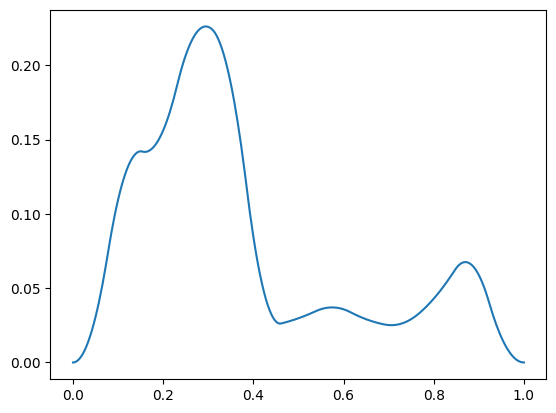

In [107]:
thompson_sampler.get_spline().plot(segmented=False)

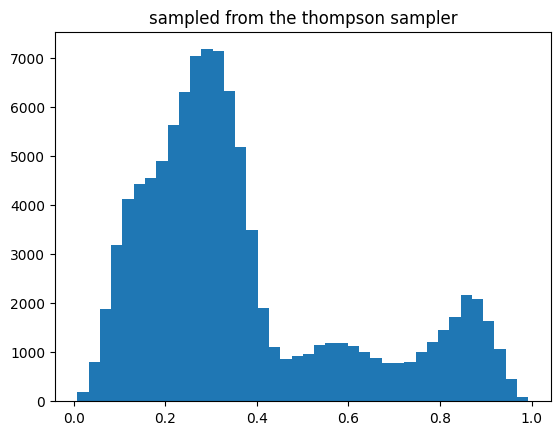

In [108]:
plt.hist(thompson_sampler.get_cdf_spline().sample(100_000), bins=40)
plt.title('sampled from the thompson sampler')
plt.show()

In [109]:
# I'd say that fits the distribution estimated by the thompson sampler

In [110]:
%%time
thompson_sampler.get_cdf_spline().sample(100_000)

CPU times: total: 4.38 s
Wall time: 4.38 s


array([0.23261898, 0.1401326 , 0.04251989, ..., 0.35619567, 0.3078108 ,
       0.10949031])

In [114]:
%%time
thompson_sampler.get_cdf_spline().sample(1)

CPU times: total: 0 ns
Wall time: 0 ns


0.2737898917967474

## FlexibleDensityEstimator

In [115]:
from spline_filter.tensorflow.distribution import FlexibleDensityEstimator

## Train PDF

In [116]:
estimator = FlexibleDensityEstimator(3)

In [117]:
spline = estimator.get_spline()

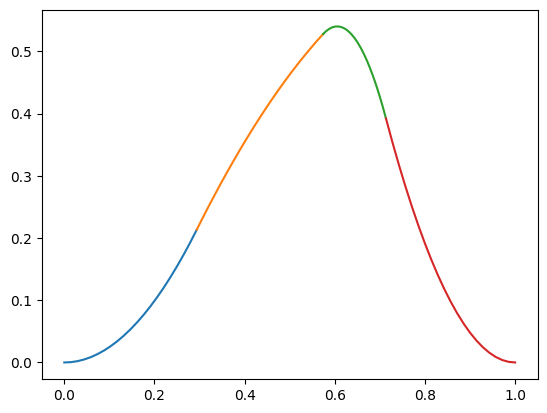

In [118]:
spline.plot()

In [119]:
estimator.area()

0.27408227916284966

In [120]:
estimator.expected_value()

0.5343790260115159

In [121]:
import tensorflow as tf
import numpy as np

In [122]:
ts = tf.convert_to_tensor(np.random.normal(0.5, 0.05, size=100_000), dtype=tf.float64)

In [123]:
estimator.train(ts, n_epochs=20, batch_size=4096)

Epoch 1/20 18.55515834899972
Epoch 2/20 18.072135755811093
Epoch 3/20 17.705224161446157
Epoch 4/20 17.44225570464915
Epoch 5/20 17.253125585277683
Epoch 6/20 17.09854882200074
Epoch 7/20 16.938090198320836
Epoch 8/20 16.737805492392773
Epoch 9/20 16.475079980728566
Epoch 10/20 16.140306796806108
Epoch 11/20 15.736900063635241
Epoch 12/20 15.279356072985964
Epoch 13/20 14.788795419772876
Epoch 14/20 14.287248615191949
Epoch 15/20 13.793294486954833
Epoch 16/20 13.320192893421082
Epoch 17/20 12.875649067600769
Epoch 18/20 12.462756389265506
Epoch 19/20 12.081199267062448
Epoch 20/20 11.728705345988233


In [124]:
spline = estimator.get_spline()

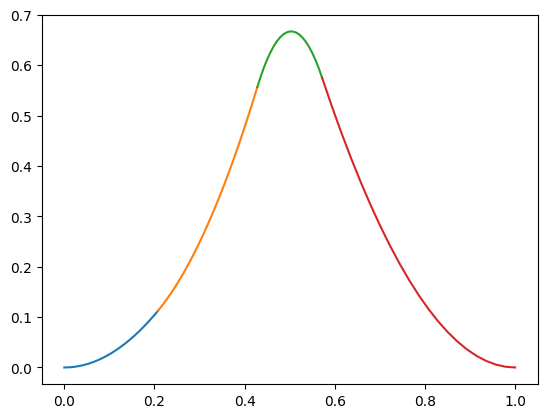

In [125]:
spline.plot()

In [126]:
estimator.expected_value()

0.4985860736695392

## Train CDF

In [127]:
estimator = FlexibleDensityEstimator(7)

In [128]:
spline = estimator.get_spline()

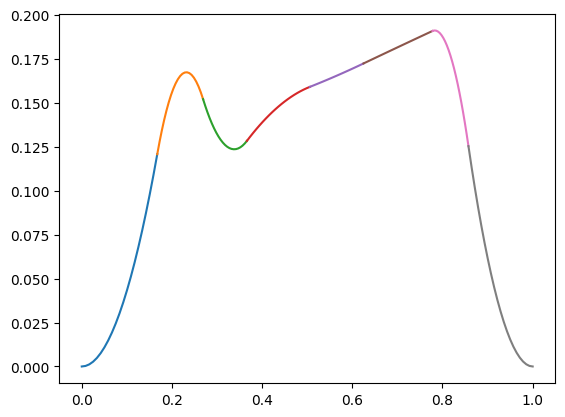

In [129]:
spline.plot()

In [130]:
estimator.expected_value()

0.5211259193593923

In [131]:
ts = tf.convert_to_tensor(np.random.normal(0.5, 0.05, size=100_000), dtype=tf.float64)
t_preds = tf.convert_to_tensor(np.random.uniform(size=100_000), dtype=tf.float64)
over_pred_vec = tf.where(t_preds > ts, 1.0, 0.0)

In [132]:
estimator.train_cdf(t_preds, over_pred_vec, n_epochs=20, batch_size=1024)

Epoch 1/20 23.16508249759548
Epoch 2/20 20.969781479406546
Epoch 3/20 18.967779223589634
Epoch 4/20 17.19181740642124
Epoch 5/20 15.656265173948716
Epoch 6/20 14.35798666653584
Epoch 7/20 13.281623621055203
Epoch 8/20 12.404740108714714
Epoch 9/20 11.701502176386347
Epoch 10/20 11.145140862533713
Epoch 11/20 10.709805990072276
Epoch 12/20 10.371928737392444
Epoch 13/20 10.110991580764464
Epoch 14/20 9.90981334017528
Epoch 15/20 9.754413268813106
Epoch 16/20 9.63366713104499
Epoch 17/20 9.538907153247738
Epoch 18/20 9.4634989265161
Epoch 19/20 9.402437072570779
Epoch 20/20 9.35199716561792


In [133]:
spline = estimator.get_spline()

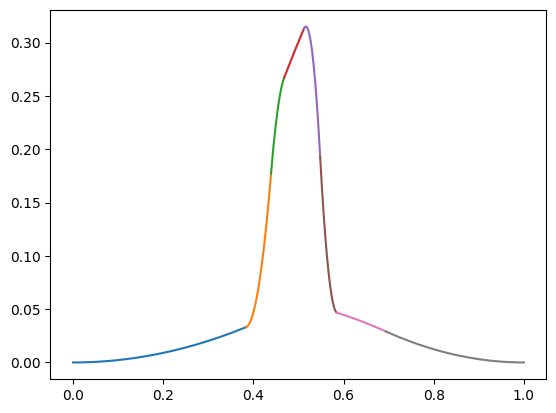

In [134]:
spline.plot()

In [135]:
estimator.expected_value()

0.43000796728398866

### Try the auction simulation again

In [136]:
n_bidders = 5
n_items = 100_000
values = np.random.uniform(size=n_items)
get_smart_p = np.random.uniform(size=(n_items, n_bidders))
perceptions = np.sqrt(np.random.uniform(size=(n_items, n_bidders)) * values.reshape((-1, 1)))
perceptions = np.where(get_smart_p > 0.9, perceptions, perceptions / 3)

In [137]:
normal_bids = perceptions.max(axis=1)

In [138]:
normal_bids.shape

(100000,)

In [139]:
(get_smart_p.max(axis=1) > 0.9).sum()

40675

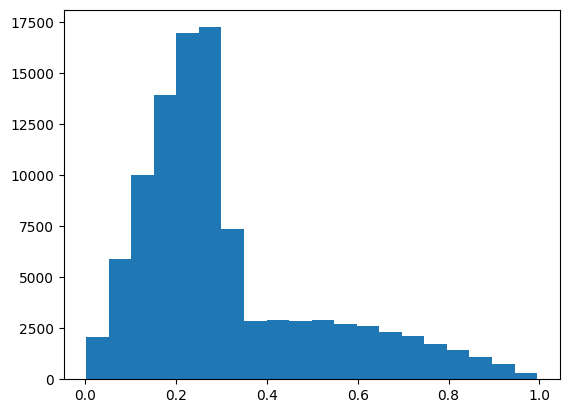

In [140]:
import matplotlib.pyplot as plt
plt.hist(normal_bids, bins=20)
plt.show()

In [141]:
bid_estimator = FlexibleDensityEstimator(7)

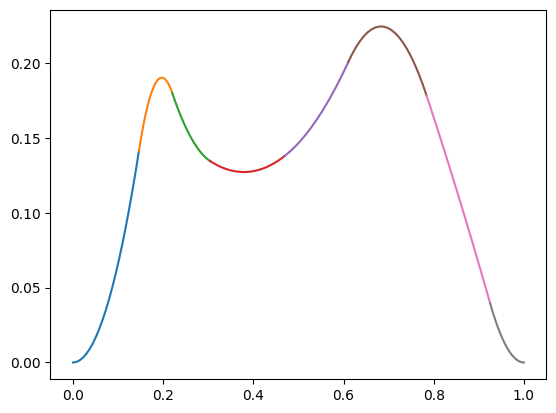

In [142]:
bid_estimator.get_spline().plot()

In [143]:
bid_estimator.train(tf.convert_to_tensor(normal_bids, dtype=tf.float64), n_epochs=20, batch_size=1024)

Epoch 1/20 193.56765756403533
Epoch 2/20 186.44500191010337
Epoch 3/20 180.22568261854732
Epoch 4/20 174.1655938885787
Epoch 5/20 168.29944702965227
Epoch 6/20 162.7549473548275
Epoch 7/20 157.45673480804442
Epoch 8/20 152.29971410597446
Epoch 9/20 147.21747893652622
Epoch 10/20 142.13701936610425
Epoch 11/20 136.90127036397746
Epoch 12/20 131.30903652484992
Epoch 13/20 125.30674267832427
Epoch 14/20 119.11964874383764
Epoch 15/20 113.14622414563965
Epoch 16/20 107.72421777979449
Epoch 17/20 103.0114681573532
Epoch 18/20 99.00794259548742
Epoch 19/20 95.63365008381707
Epoch 20/20 92.78581865525817


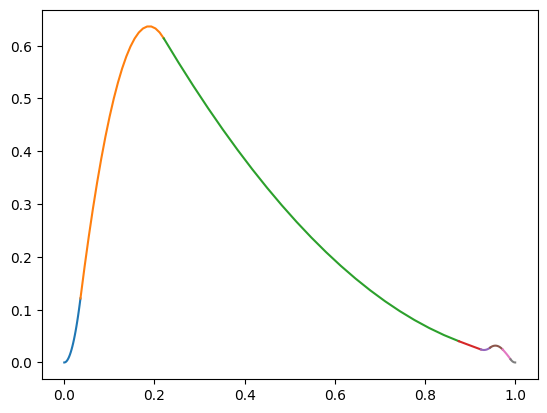

In [144]:
bid_estimator.get_spline().plot()

In [145]:
bid_estimator.expected_value()

0.4267868717355458

In [146]:
normal_bids.mean()

0.3103855080985147

#### Look at it, it's beautiful

Now I want to train a distribution that looks at what happens if we interfere

In [147]:
floor_estimator = FlexibleDensityEstimator(12)

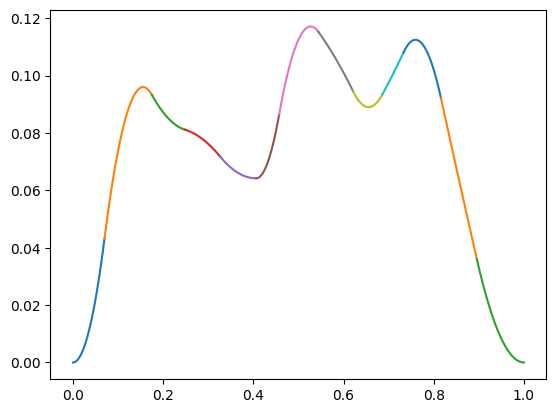

In [148]:
floor_estimator.get_spline().plot()

In [149]:
floors = np.random.uniform(0.01, 0.99, size=100_000)
new_bids = np.where(floors > normal_bids, 0.0, np.maximum(floors, normal_bids))
over_pred_vec = (new_bids == 0).astype(int)

In [150]:
floor_estimator.train_cdf(
    tf.convert_to_tensor(floors, dtype=tf.float64),
    tf.convert_to_tensor(over_pred_vec, dtype=tf.float64),
    n_epochs=20,
    batch_size=1024)

Epoch 1/20 45.19511808007781
Epoch 2/20 40.52674671939368
Epoch 3/20 37.53262387452045
Epoch 4/20 35.715807464380624
Epoch 5/20 34.679445871454924
Epoch 6/20 34.12325518769591
Epoch 7/20 33.83614853326343
Epoch 8/20 33.686519849580066
Epoch 9/20 33.60231673975957
Epoch 10/20 33.54860973978413
Epoch 11/20 33.509986260646755
Epoch 12/20 33.47992296599938
Epoch 13/20 33.45556274598801
Epoch 14/20 33.43550516189272
Epoch 15/20 33.418939958517015
Epoch 16/20 33.40530566097582
Epoch 17/20 33.39415131099204
Epoch 18/20 33.385082783713145
Epoch 19/20 33.37774579723606
Epoch 20/20 33.37182348187274


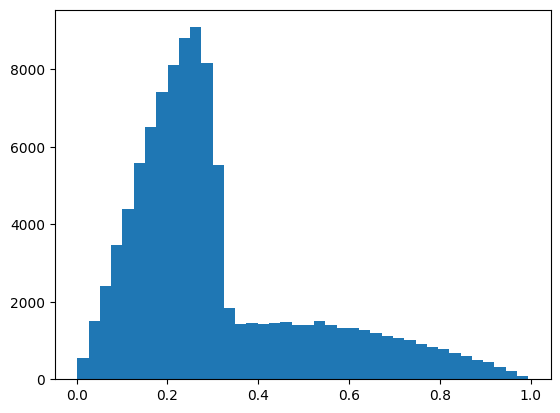

In [151]:
plt.hist(normal_bids, bins=40)
plt.show()

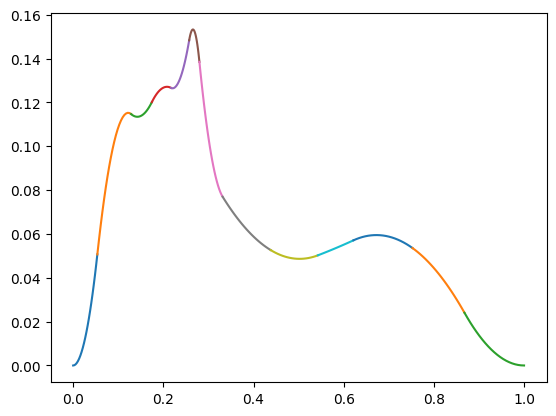

In [152]:
floor_estimator.get_spline().plot()

### I have no idea why training on the CDF is working so much better than training on the PDF

In [153]:
floor_estimator = FlexibleDensityEstimator(12)

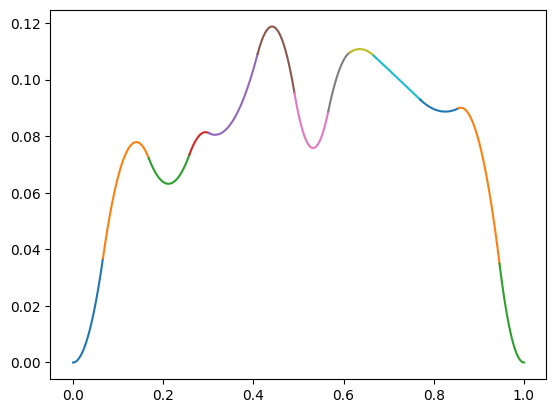

In [154]:
floor_estimator.get_spline().plot()

In [155]:
floors = np.random.uniform(0.01, 0.99, size=100_000)
new_bids = np.where(floors > normal_bids * 1.5, 0.0, np.maximum(floors, normal_bids))
over_pred_vec = (new_bids == 0).astype(int)

In [156]:
floor_estimator.train_cdf(
    tf.convert_to_tensor(floors, dtype=tf.float64),
    tf.convert_to_tensor(over_pred_vec, dtype=tf.float64),
    n_epochs=20,
    batch_size=1024)

Epoch 1/20 49.119757668167146
Epoch 2/20 47.625426240016075
Epoch 3/20 46.85761243628046
Epoch 4/20 46.37782036068394
Epoch 5/20 46.026031464110396
Epoch 6/20 45.74980986162139
Epoch 7/20 45.52782406375197
Epoch 8/20 45.347520306233186
Epoch 9/20 45.19960235787675
Epoch 10/20 45.076726568474115
Epoch 11/20 44.97319536177626
Epoch 12/20 44.884671562292134
Epoch 13/20 44.80798856053685
Epoch 14/20 44.74088025514896
Epoch 15/20 44.68171358429098
Epoch 16/20 44.62930295906006
Epoch 17/20 44.58276033648042
Epoch 18/20 44.54138675520169
Epoch 19/20 44.504599979375335
Epoch 20/20 44.47189794510982


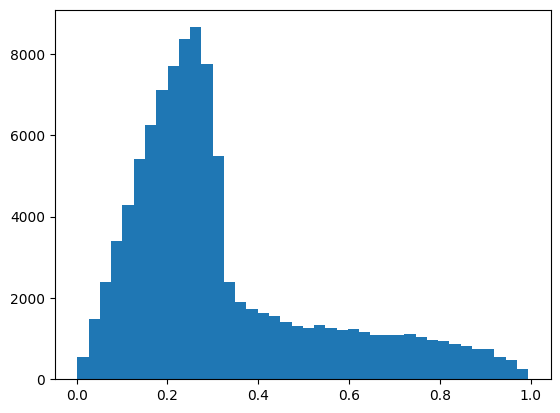

In [157]:
plt.hist(np.where(new_bids == 0, normal_bids, new_bids), bins=40)
plt.show()

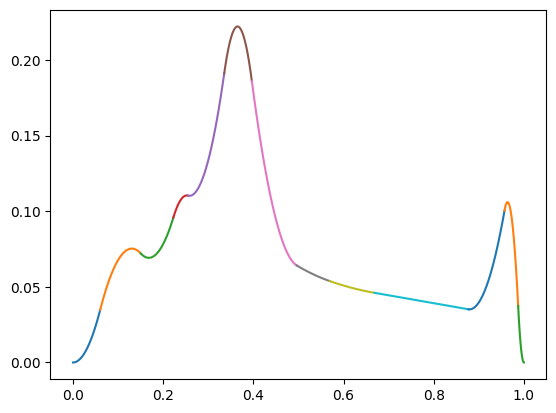

In [158]:
floor_estimator.get_spline().plot()

### There are some artifacts in the flexible estimator that I'm not quite able to understand

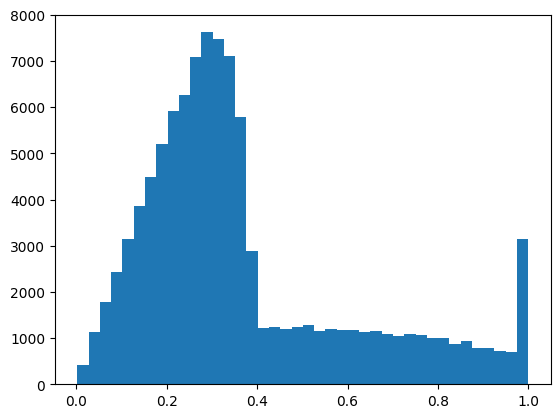

In [161]:
plt.hist(max_bids, bins=40);